# Sudoku board threshold experiment

Ten notebook zaczyna eksperyment od zera i celowo zatrzymuje się na etapie:
- wczytanie obrazu,
- grayscale,
- odszumianie,
- `adaptive threshold`.

Nie ma tutaj jeszcze:
- korekcji EXIF,
- wykrywania ramki planszy,
- perspektywy / warp,
- cięcia na siatkę 9x9.

To ma być mały, szybki poligon do porównywania wariantów preprocessingu na obrazkach z datasetu. Kolejne bloki będziemy dokładać dopiero wtedy, gdy ten etap będzie stabilny.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (16, 10)
plt.rcParams["image.cmap"] = "gray"
plt.rcParams["axes.grid"] = False

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def find_repo_root(start_path: Path | None = None) -> Path:
    current_path = (start_path or Path.cwd()).resolve()
    for candidate in [current_path, *current_path.parents]:
        if (candidate / ".git").exists() or (candidate / ".ai").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root from the current working directory.")


REPO_ROOT = find_repo_root()
DRAFT_DIR = REPO_ROOT / "src" / "MachineLearning" / "draft"


@dataclass(slots=True)
class ExperimentConfig:
    dataset_root: Path = REPO_ROOT / "data" / "raw" / "boards"
    image_path: Path | None = None
    selected_dataset_index: int = 0
    preview_limit: int = 20
    max_display_size: int = 1600
    gaussian_kernel_size: tuple[int, int] = (5, 5)
    median_kernel_size: int = 5
    bilateral_diameter: int = 9
    bilateral_sigma_color: int = 75
    bilateral_sigma_space: int = 75
    nl_means_strength: int = 13
    nl_means_template_window_size: int = 7
    nl_means_search_window_size: int = 21
    adaptive_method_name: str = "gaussian"
    adaptive_block_sizes: tuple[int, ...] = (11, 15, 21, 31)
    adaptive_c_values: tuple[int, ...] = (2, 4, 6)
    threshold_invert: bool = True
    selected_denoise_variant: str = "median_5"
    selected_threshold_name: str | None = None


CONFIG = ExperimentConfig()

print(f"Repo root: {REPO_ROOT}")
print(f"Draft dir:  {DRAFT_DIR}")
print(f"Dataset root (current): {CONFIG.dataset_root}")

Repo root: /home/wojtek/projects/sudoku
Draft dir:  /home/wojtek/projects/sudoku/src/MachineLearning/draft
Dataset root (current): /home/wojtek/projects/sudoku/data/raw/boards


In [2]:
def discover_dataset_images(dataset_root: Path) -> list[Path]:
    if not dataset_root.exists():
        return []

    return sorted(
        path
        for path in dataset_root.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def path_for_display(path: Path, base_path: Path) -> str:
    try:
        return str(path.relative_to(base_path))
    except ValueError:
        return str(path)


def resolve_active_image_path(config: ExperimentConfig) -> tuple[Path, list[Path]]:
    dataset_images = discover_dataset_images(config.dataset_root)

    if config.image_path is not None:
        image_path = config.image_path.resolve()
        if not image_path.exists():
            raise FileNotFoundError(f"Configured image does not exist: {image_path}")
        return image_path, dataset_images

    if not dataset_images:
        raise FileNotFoundError(
            "No dataset images found. Set CONFIG.dataset_root or CONFIG.image_path first."
        )

    selected_index = max(0, min(config.selected_dataset_index, len(dataset_images) - 1))
    return dataset_images[selected_index], dataset_images


def load_image_bgr(image_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")
    return image


def resize_for_display(image: np.ndarray, max_dimension: int) -> np.ndarray:
    height, width = image.shape[:2]
    longest_dimension = max(height, width)
    if longest_dimension <= max_dimension:
        return image.copy()

    scale = max_dimension / float(longest_dimension)
    resized_width = max(1, int(round(width * scale)))
    resized_height = max(1, int(round(height * scale)))
    return cv2.resize(
        image,
        (resized_width, resized_height),
        interpolation=cv2.INTER_AREA,
    )


def to_rgb(image_bgr: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def plot_named_images(
    named_images: list[tuple[str, np.ndarray, bool]],
    *,
    columns: int = 3,
    figure_scale: float = 5.0,
) -> None:
    if not named_images:
        raise ValueError("No images to display.")

    rows = int(np.ceil(len(named_images) / columns))
    figure, axes = plt.subplots(rows, columns, figsize=(columns * figure_scale, rows * figure_scale))
    axes_array = np.atleast_1d(axes).reshape(rows, columns)

    for axis in axes_array.flat:
        axis.axis("off")

    for axis, (title, image, is_bgr) in zip(axes_array.flat, named_images):
        display_image = to_rgb(image) if is_bgr else image
        axis.imshow(display_image)
        axis.set_title(title)
        axis.axis("off")

    figure.tight_layout()
    plt.show()


def build_denoise_variants(
    gray_image: np.ndarray,
    config: ExperimentConfig,
) -> dict[str, np.ndarray]:
    return {
        "raw_gray": gray_image,
        f"gaussian_{config.gaussian_kernel_size[0]}": cv2.GaussianBlur(
            gray_image,
            config.gaussian_kernel_size,
            0,
        ),
        f"median_{config.median_kernel_size}": cv2.medianBlur(
            gray_image,
            config.median_kernel_size,
        ),
        "bilateral": cv2.bilateralFilter(
            gray_image,
            config.bilateral_diameter,
            config.bilateral_sigma_color,
            config.bilateral_sigma_space,
        ),
        "nl_means": cv2.fastNlMeansDenoising(
            gray_image,
            None,
            h=config.nl_means_strength,
            templateWindowSize=config.nl_means_template_window_size,
            searchWindowSize=config.nl_means_search_window_size,
        ),
    }


def adaptive_method_code(method_name: str) -> int:
    normalized_method_name = method_name.strip().lower()
    if normalized_method_name == "mean":
        return cv2.ADAPTIVE_THRESH_MEAN_C
    if normalized_method_name == "gaussian":
        return cv2.ADAPTIVE_THRESH_GAUSSIAN_C
    raise ValueError(f"Unsupported adaptive method: {method_name}")


def build_threshold_variants(
    denoised_image: np.ndarray,
    config: ExperimentConfig,
) -> dict[str, np.ndarray]:
    threshold_variants: dict[str, np.ndarray] = {}
    method_code = adaptive_method_code(config.adaptive_method_name)
    threshold_type = cv2.THRESH_BINARY_INV if config.threshold_invert else cv2.THRESH_BINARY

    for block_size in config.adaptive_block_sizes:
        if block_size % 2 == 0:
            raise ValueError(f"Adaptive block size must be odd: {block_size}")

        for c_value in config.adaptive_c_values:
            variant_name = (
                f"{config.adaptive_method_name}_block{block_size}_c{c_value}"
            )
            threshold_variants[variant_name] = cv2.adaptiveThreshold(
                denoised_image,
                255,
                method_code,
                threshold_type,
                block_size,
                c_value,
            )

    return threshold_variants

## 1. Wybór obrazka

Są dwa tryby pracy:
1. ręczne wpisanie ścieżki do konkretnego obrazka,
2. automatyczny wybór pliku z `CONFIG.dataset_root` po indeksie.

Najprostszy workflow:
1. wpisz ścieżkę w komórce poniżej, jeśli chcesz pracować na jednym konkretnym obrazie,
2. jeśli pole zostanie puste, notebook użyje `CONFIG.dataset_root` i `CONFIG.selected_dataset_index`,
3. uruchom dalsze komórki.

Domyślnie **nie** stosujemy żadnej automatycznej korekcji orientacji. Chcemy zobaczyć obraz dokładnie takim, jaki trafia do pipeline'u.

In [ ]:
IMAGE_PATH_INPUT = ""
# Przykład:
# IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/data/raw/boards/przyklad/board_01.jpg"
# IMAGE_PATH_INPUT = "data/raw/boards/przyklad/board_01.jpg"

if IMAGE_PATH_INPUT.strip():
    typed_image_path = Path(IMAGE_PATH_INPUT).expanduser()
    if not typed_image_path.is_absolute():
        typed_image_path = (REPO_ROOT / typed_image_path).resolve()

    CONFIG.image_path = typed_image_path
    print(f"Manual image path enabled: {CONFIG.image_path}")
else:
    CONFIG.image_path = None
    print("Manual image path is empty. Notebook will use dataset_root + selected_dataset_index.")

In [3]:
ACTIVE_IMAGE_PATH, DATASET_IMAGES = resolve_active_image_path(CONFIG)

print(f"Found {len(DATASET_IMAGES)} image(s) under dataset root.")
preview_paths = DATASET_IMAGES[: CONFIG.preview_limit]
for index, path in enumerate(preview_paths):
    marker = "<-- selected" if path == ACTIVE_IMAGE_PATH else ""
    print(f"[{index:02d}] {path_for_display(path, CONFIG.dataset_root)} {marker}")

if len(DATASET_IMAGES) > CONFIG.preview_limit:
    print(f"... and {len(DATASET_IMAGES) - CONFIG.preview_limit} more")

print()
print(f"Active image: {ACTIVE_IMAGE_PATH}")

Found 559 image(s) under dataset root.
[00] mixed/image1005.jpg <-- selected
[01] mixed/image1009.jpg 
[02] mixed/image1019.jpg 
[03] mixed/image1024.jpg 
[04] mixed/image1041.jpg 
[05] mixed/image1072.jpg 
[06] mixed/image1073.jpg 
[07] mixed/image1080.jpg 
[08] mixed/image1088.jpg 
[09] mixed/image114.jpg 
[10] mixed/image117.jpg 
[11] mixed/image120.jpg 
[12] mixed/image126.jpg 
[13] mixed/image140.jpg 
[14] mixed/image148.jpg 
[15] mixed/image153.jpg 
[16] mixed/image166.jpg 
[17] mixed/image175.jpg 
[18] mixed/image176.jpg 
[19] mixed/image179.jpg 
... and 539 more

Active image: /home/wojtek/projects/sudoku/data/raw/boards/mixed/image1005.jpg


Original shape: (1280, 960, 3)
Display shape:  (1280, 960, 3)


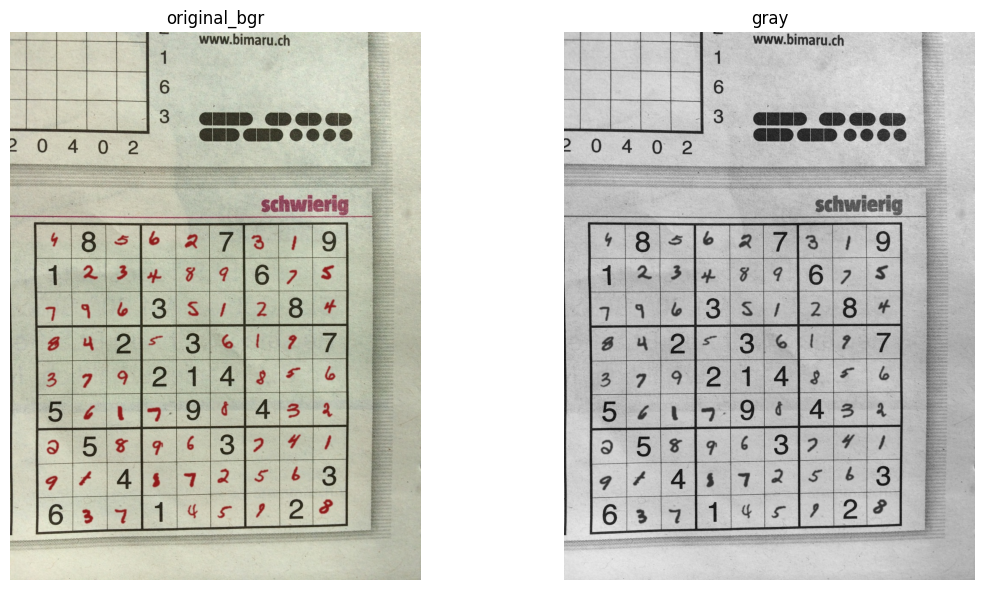

In [4]:
source_bgr = load_image_bgr(ACTIVE_IMAGE_PATH)
display_bgr = resize_for_display(source_bgr, CONFIG.max_display_size)
gray_image = cv2.cvtColor(display_bgr, cv2.COLOR_BGR2GRAY)

print(f"Original shape: {source_bgr.shape}")
print(f"Display shape:  {display_bgr.shape}")

plot_named_images(
    [
        ("original_bgr", display_bgr, True),
        ("gray", gray_image, False),
    ],
    columns=2,
    figure_scale=6,
)

## 2. Odszumianie

Najpierw porównujemy kilka prostych wariantów odszumiania. Na tym etapie chodzi tylko o szybkie sprawdzenie, który wariant najlepiej zachowuje linie siatki i nie rozmywa ich zbyt agresywnie.

Available denoise variants:
- raw_gray 
- gaussian_5 
- median_5 <-- selected
- bilateral 
- nl_means 


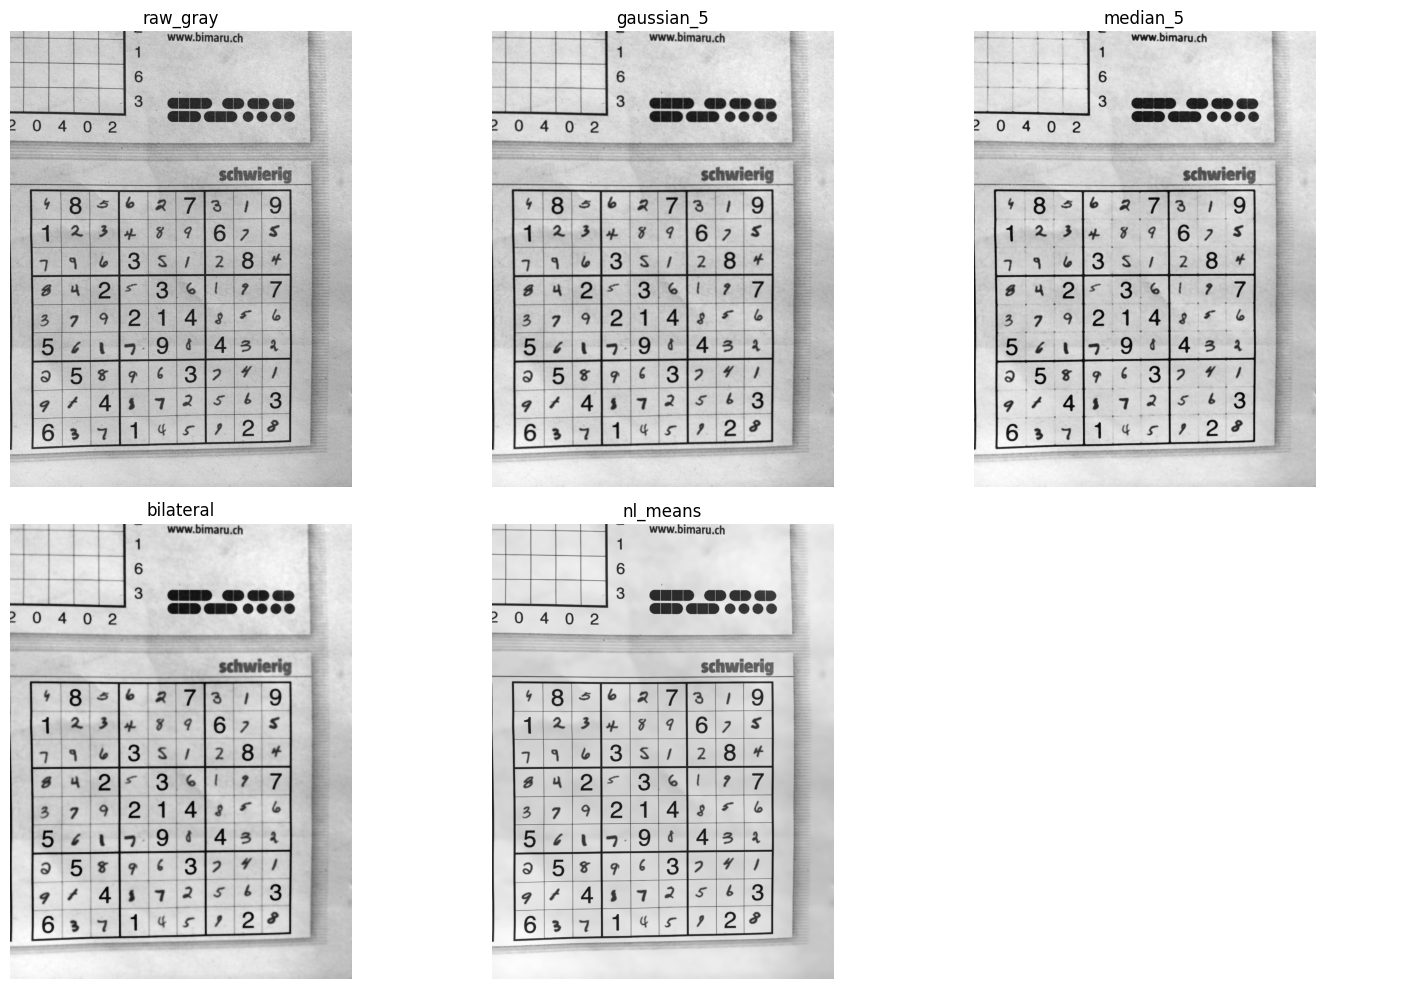

In [5]:
denoise_variants = build_denoise_variants(gray_image, CONFIG)
selected_denoise_image = denoise_variants[CONFIG.selected_denoise_variant]

print("Available denoise variants:")
for variant_name in denoise_variants:
    marker = "<-- selected" if variant_name == CONFIG.selected_denoise_variant else ""
    print(f"- {variant_name} {marker}")

plot_named_images(
    [
        (variant_name, variant_image, False)
        for variant_name, variant_image in denoise_variants.items()
    ],
    columns=3,
    figure_scale=5,
)

## 3. Adaptive threshold

Dalej porównujemy kilka kombinacji `blockSize` i `C` na jednym, wybranym wariancie odszumiania. To jest obecny koniec pipeline'u eksperymentalnego. Wszystko poniżej ma już bazować na obrazie wybranym w tej sekcji.

Adaptive method: gaussian
Selected denoise variant: median_5

Available threshold variants:
- gaussian_block11_c2 <-- selected
- gaussian_block11_c4 
- gaussian_block11_c6 
- gaussian_block15_c2 
- gaussian_block15_c4 
- gaussian_block15_c6 
- gaussian_block21_c2 
- gaussian_block21_c4 
- gaussian_block21_c6 
- gaussian_block31_c2 
- gaussian_block31_c4 
- gaussian_block31_c6 


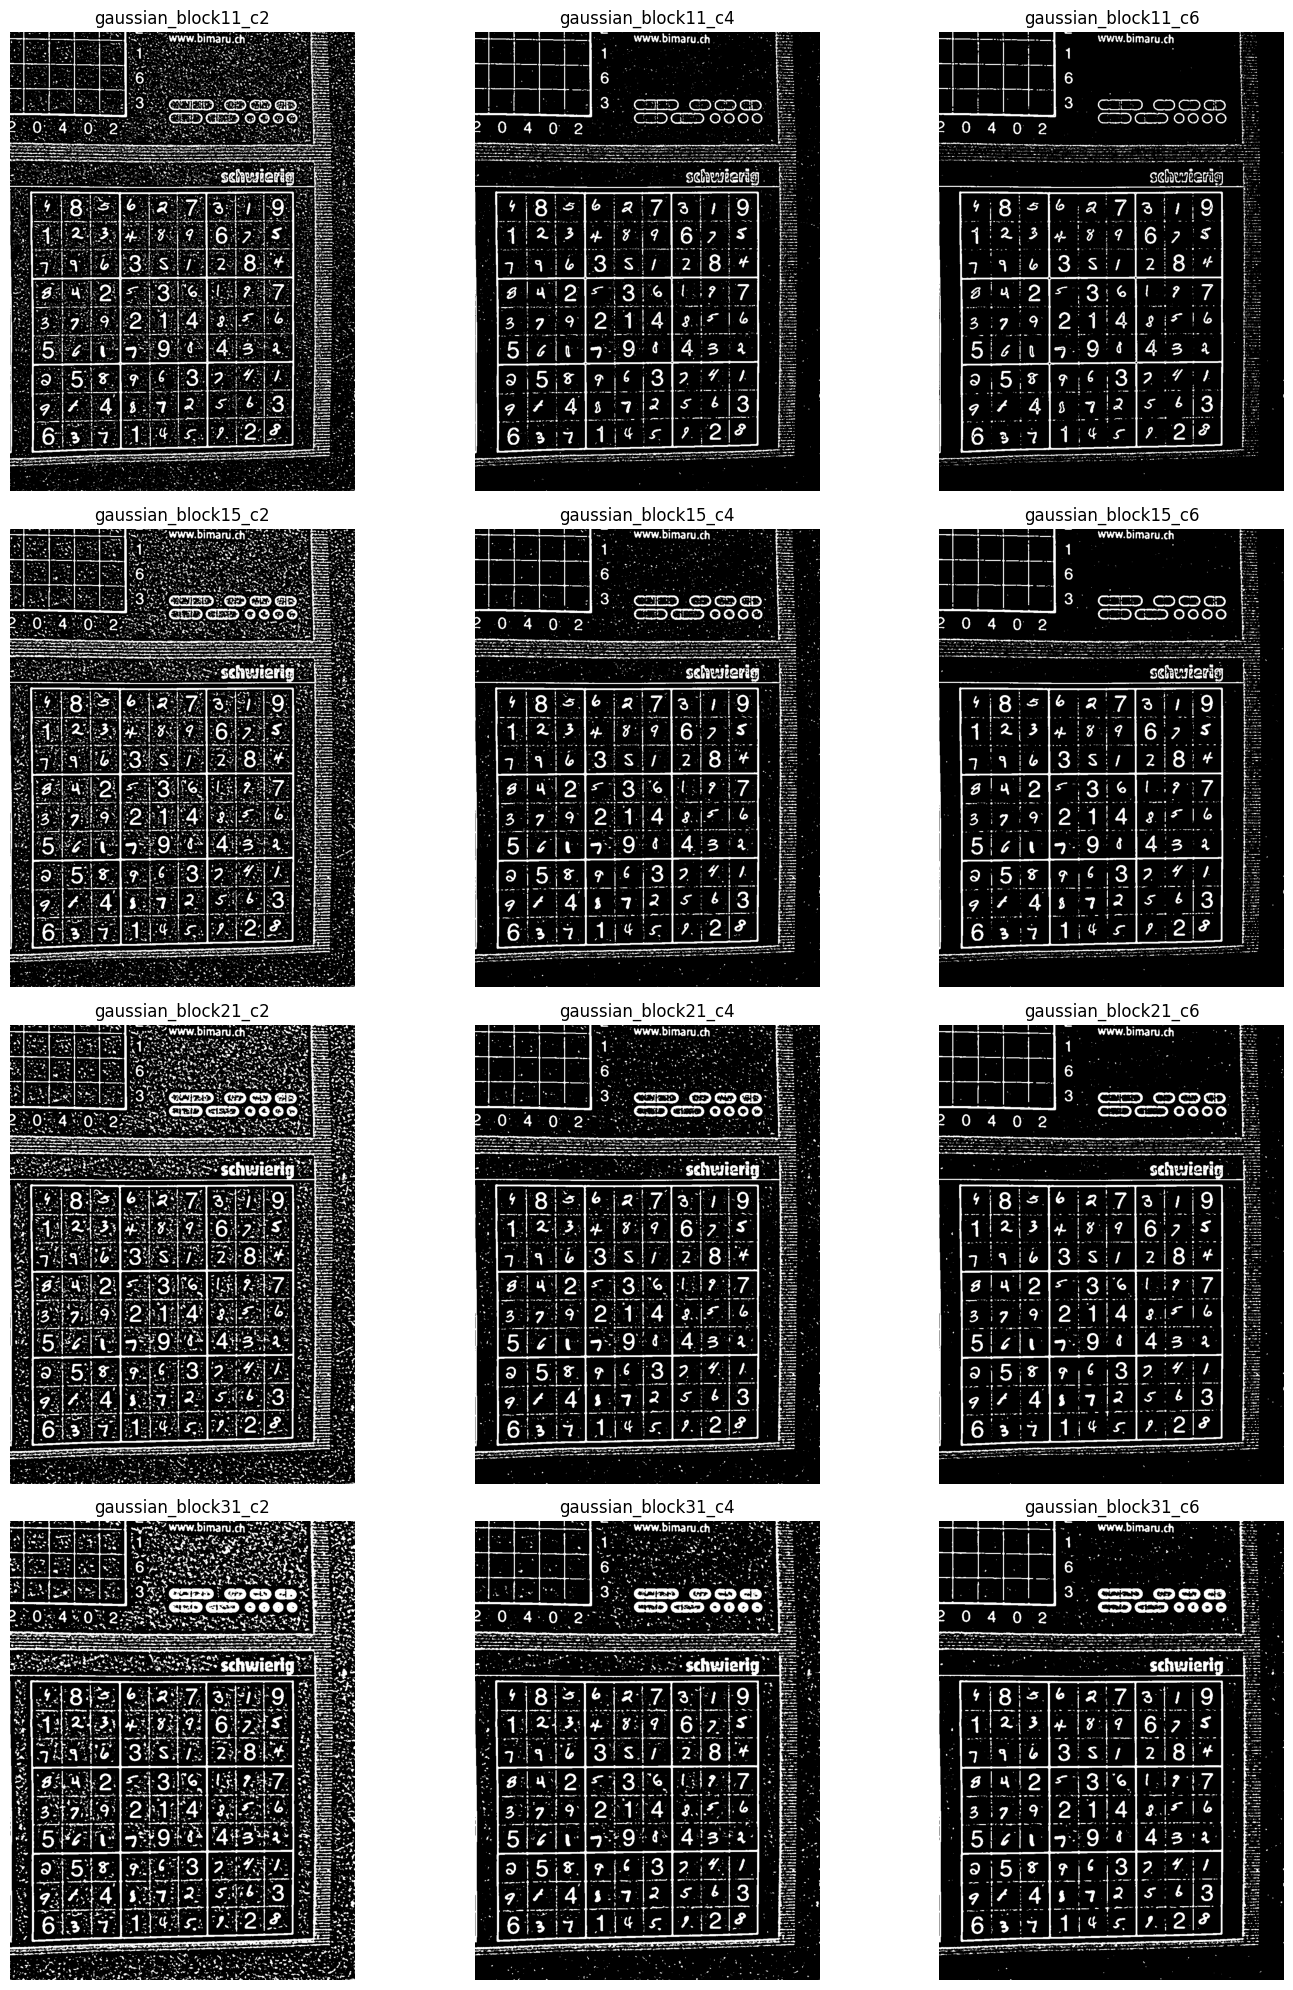

In [6]:
threshold_variants = build_threshold_variants(selected_denoise_image, CONFIG)

if CONFIG.selected_threshold_name is None:
    SELECTED_THRESHOLD_NAME = next(iter(threshold_variants))
else:
    SELECTED_THRESHOLD_NAME = CONFIG.selected_threshold_name

selected_binary = threshold_variants[SELECTED_THRESHOLD_NAME]

print(f"Adaptive method: {CONFIG.adaptive_method_name}")
print(f"Selected denoise variant: {CONFIG.selected_denoise_variant}")
print()
print("Available threshold variants:")
for variant_name in threshold_variants:
    marker = "<-- selected" if variant_name == SELECTED_THRESHOLD_NAME else ""
    print(f"- {variant_name} {marker}")

plot_named_images(
    [
        (variant_name, variant_image, False)
        for variant_name, variant_image in threshold_variants.items()
    ],
    columns=3,
    figure_scale=5,
)

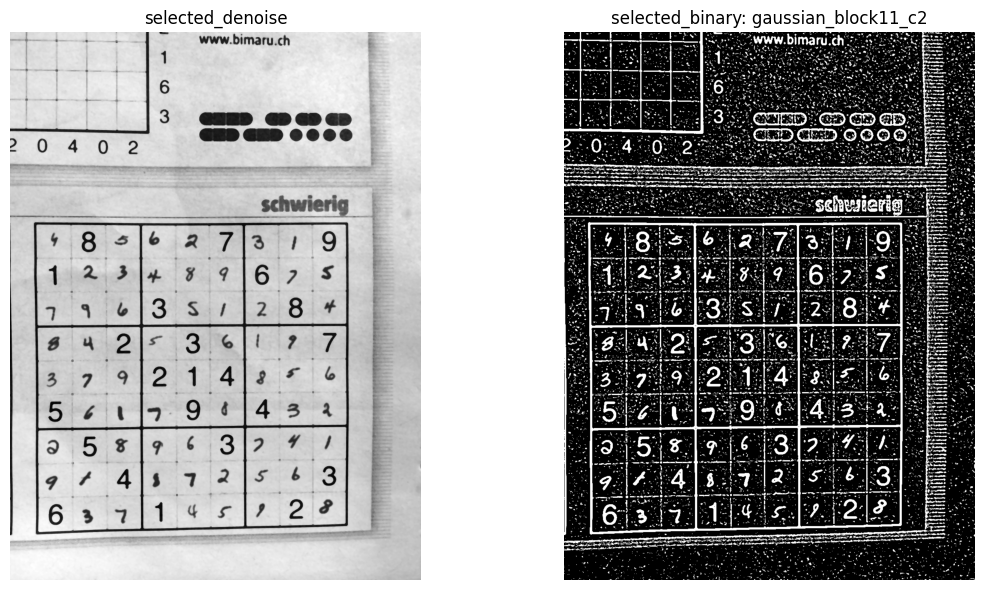

Notebook intentionally stops here.
Next blocks should start from `selected_binary`, instead of bringing back old board-detection logic.


In [7]:
plot_named_images(
    [
        ("selected_denoise", selected_denoise_image, False),
        (f"selected_binary: {SELECTED_THRESHOLD_NAME}", selected_binary, False),
    ],
    columns=2,
    figure_scale=6,
)

print("Notebook intentionally stops here.")
print("Next blocks should start from `selected_binary`, instead of bringing back old board-detection logic.")